1. # Practical 2 report: from relationships to predictive models

**Student:** Oleksandra Tsepilova

**Date:** 18.09.2026

**Practical:** 2 - Regression and evaluation


In [8]:
import dcor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 180926

## 2. Data-preparation readiness

Complete the checklist before describing modelling results. Tick an item only after checking the data or documenting a justified decision.

### Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly? 

**Answer:** Yes, we want to predict quantitative target representing diabetes progression from physiological measurements of the patient.
- [x] Is the unit of observation clear?

**Answer**: Yes, unit of observation (one row) is one patient
- [x] Do I know where the data came from, how they were generated, and under which access conditions they may be used?

**Answer:** Yes, shared by sklearn so license allows usage, original authors can be found in the sklearn documentation.
- [x] Have I recorded the data version, processing history, and transformations already applied?

**Answer:** As we take dataset from sklearn, having recorded version of sklearn in env should be enough.

### Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?

**Answer:** Yes, visually inspecting it doesn't seem like any columns or rows are composite, the number of rows corresponds to the number of patients from documentation and same can be said about columns - they are exactly as documented, and each of them corresponds to different body measurement or patient characteristic.
- [x] If needed, have I transposed the original assay into the format expected by the analysis tool?

**Answer:** Not needed, we already have features as columns and samples (patients) as rows.
- [x] Are row names, column names, and identifiers clear, unique, and stable?

**Answer:** For columns - yes, for rows we can think of ids as such.
- [x] Can every feature and observation be traced to its source?

**Answer:** Yes.
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than row order?

**Answer:** Not aplicable, as we don't have separate metadata table

In [9]:
diabetes = load_diabetes(as_frame=True)
diabetes_df = diabetes.frame.copy()
diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


### Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?

**Answer:** All columns seem to be numerical (float64), however this doesn't really correspond to the meaning for sex column, which should be categorical. As explained in the documentation, feature variables have been mean centered and scaled by the standard deviation times the square root of n_samples, which explains why we have. values like this. Also it is likely that originally age column consisted of only integers.
- [x] Are units, scales, encodings, reference categories, and detection limits understood?

**Answer:** The units explanation can be found in documentation, but the data is standardized, which makes understanding units in current form hard.
- [x] Have impossible values, inconsistent labels, unexpected categories, constant features, and extreme values been checked?

**Answer:** Impossible values are hard to check on standardized data we have, but the histograms reveal absence of outliers, and only 2 peaks for sex column, one likely coding for male and the other for female, without additional weird values.

- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?

**Answer:** Yes, in sklearn documentation they say `feature variables have been mean centered and scaled by the standard deviation times the square root of n_samples`

In [10]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


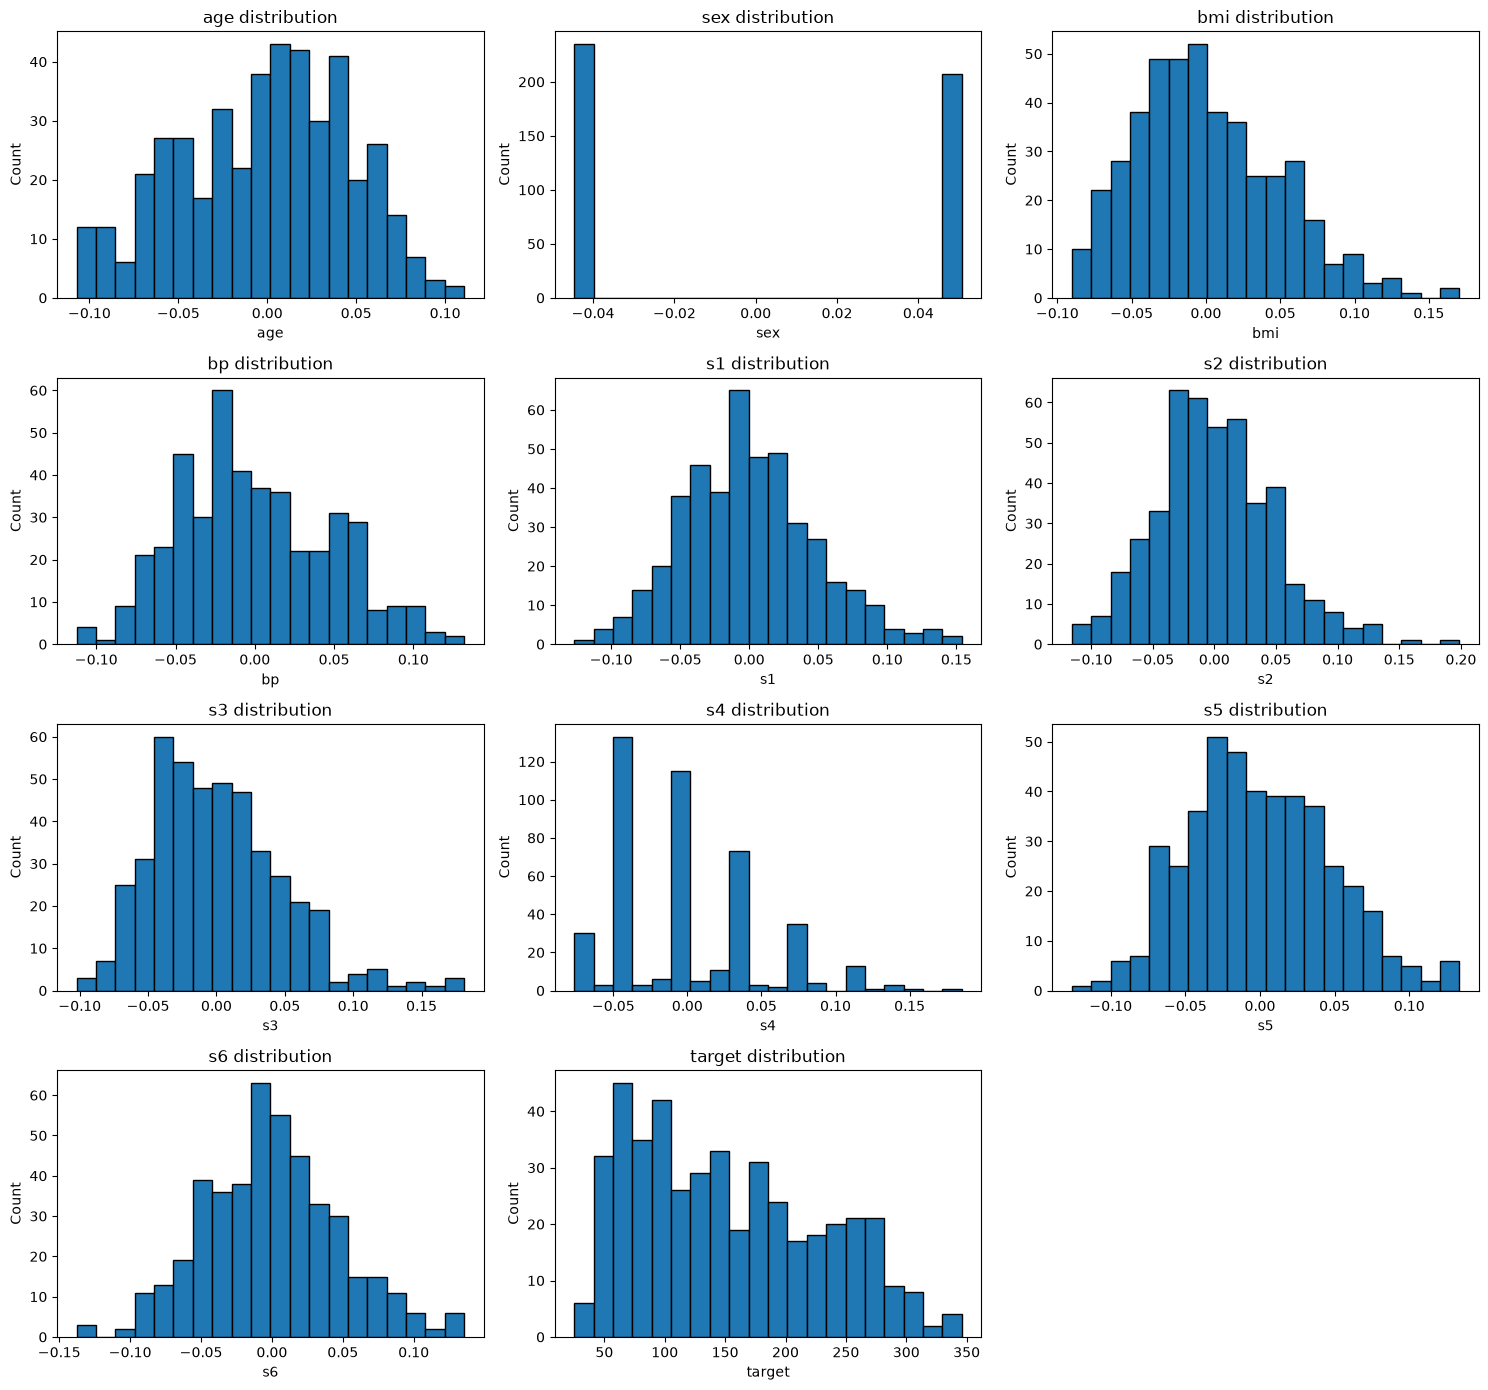

In [11]:
n_cols = 3
n_features = len(diabetes_df.columns)
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()


for i, col in enumerate(diabetes_df.columns):
    axes[i].hist(diabetes_df[col], bins=20, edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"{col} distribution")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Missing values

- [x] Have missing values been detected using all representations, not only `NaN`?

**Answer:** `df.info()` above revealed that all values in df are numerical, and no NaNs are present. It is possible that sosme missing values were represented as 0, but as the values are standardized - there is not much we can do to tell such apart.
- [x] Have missing values been measured by row, column, and relevant group?

**Answer:** No need, as we see from `df.info()` that we don't have any NaNs 
- [x] Do I know whether missingness is structural, technical, or plausibly related to biology or the target?

**Answer:** No missingness - not applcable.
- [x] Have retention, removal, or imputation been justified?

**Answer:** No missingness - not applcable.
- [x] If imputing, will the imputer be fitted on training data only?

**Answer:** No missingness - not applcable.

### Replicates, dependence, and grouping

- [x] Have exact and near-duplicate observations been checked?

**Answer:** There are no exact duplicates, near-duplicates won't be checked as it is hard to figure out thresholds under which values will be considered as duplicates for normalized data. Moreover the datasets is allegedly having each row as separate patient, so there isn't supposed to be near-duplicates in it.
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?

**Answer:** Independent samples (patients).
- [x] Is the independent biological unit identified by a grouping variable?

**Answer:** No, each sample is already independent observation.
- [x] Will related observations remain in the same train/validation/test split?

**Answer:** Yes, because each sample is an independent observation.
- [x] Is the provenance of synthetic or augmented observations recorded?

**Answer:** No, as there are none.

In [12]:
print("Exact duplicate rows", int(diabetes_df.duplicated().sum()))

Exact duplicate rows 0


### Target, leakage, confounding, and reproducibility

- [x] Is the target defined before modelling?

**Answer:** Yes, target column in the dataset (biological meaning of it is quantitative measure of disease progression).
- [x] Have identifiers, post-outcome variables, duplicated target information, and other leakage sources been excluded?

**Answer:** Yes, there don't seem to be any columns that would directly point to the disease progression state.
- [x] Have batch, site, subject, treatment, sex, age, time, and other possible confounders been considered?

**Answer:** Yes, sex, age and bmi can be confounders (affecting both disease progression quantification and measurements).
- [x] Does the planned split represent the biological generalization question?

**Answer:** Yes. Planned split is simply random (no need to stratify with regard to sex as from histogram they seem to be more or less balanced and we can expect that random split would also distribute them more or less evenly). This way the model is supposed to generalize to new patients.
- [ x] Are random seeds, software versions, file names, shapes, and preprocessing decisions recorded?

**Answer:** Yes.

**Preparation summary:**

- Biological unit: one human patient
- Number of observations and features: 442 observations and 10 features (+1 column for target)
- Target and feature definition: target - quantitative measure of disease progression. The feature columns are normalized, but originally their meaning was:
    - age age in years
    - sex
    - bmi body mass index
    - bp average blood pressure
    - s1 tc, total serum cholesterol
    - s2 ldl, low-density lipoproteins
    - s3 hdl, high-density lipoproteins
    - s4 tch, total cholesterol / HDL
    - s5 ltg, possibly log of serum triglycerides level
    - s6 glu, blood sugar level
- Missing-value decision: no missing values - no decision
- Replicate/grouping decision: no replicates and groupings
- Main confounder or leakage source: main confounder is sex
- Train/test split and justification: random, as samples are mostly balanced by sex and independent
- Remaining concerns: 
    - possible missing values represented as 0s originally and dissapearing after normalization 
    - inability to recover original values in original units and therefore complication with checking result

## 3 Your  task: Diabetes regression

### 3.1 Data presentation (already done above)

Identify:

- one observation; **Answer:** one patient.
- the target variable; **Answer:** target column, quantification of disease progression.
- predictor variables; **Answer:** physiological measurements (columns starting with s).
- dimensionality of the dataset; **Answer:** 442 rows and 11 columns.
- whether the predictors and target have physical units or transformed scales. **Answer:** trasformed scales for everything except target, which is also not in physical units.

### 3.2 Descriptive analysis

- Summarize the target.
- Visualize its distribution.
- Visualize at least three predictor-target relationships.
- State the biological or predictive question addressed by each plot.

In [13]:
diabetes_df["target"].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

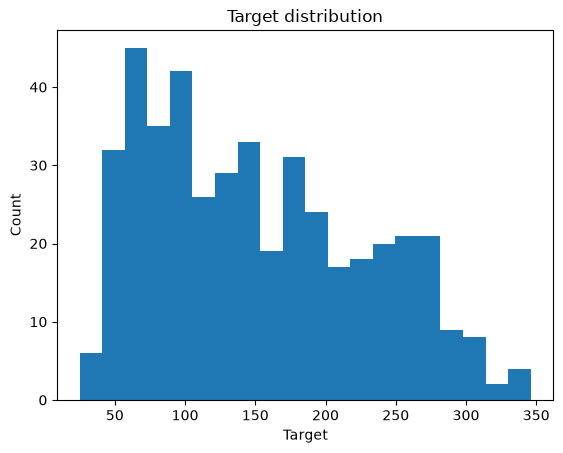

In [14]:
plt.hist(diabetes_df["target"], bins=20)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()

**Answer:** With each of the plots below, we can investigate presence of any relationship between target and predictors. For s1, s2, s3 it doesn't seem like there exist any association between them and target, but for s4, s5 and s6 it looks like there might be some connection (higher level of feature corresponding to higher quantification of disease progression). The strongest connection to the target seems to be serum triglycerides, which corresponds to common knowledge about it being both early sign of diabetes and spiking with disease progression.

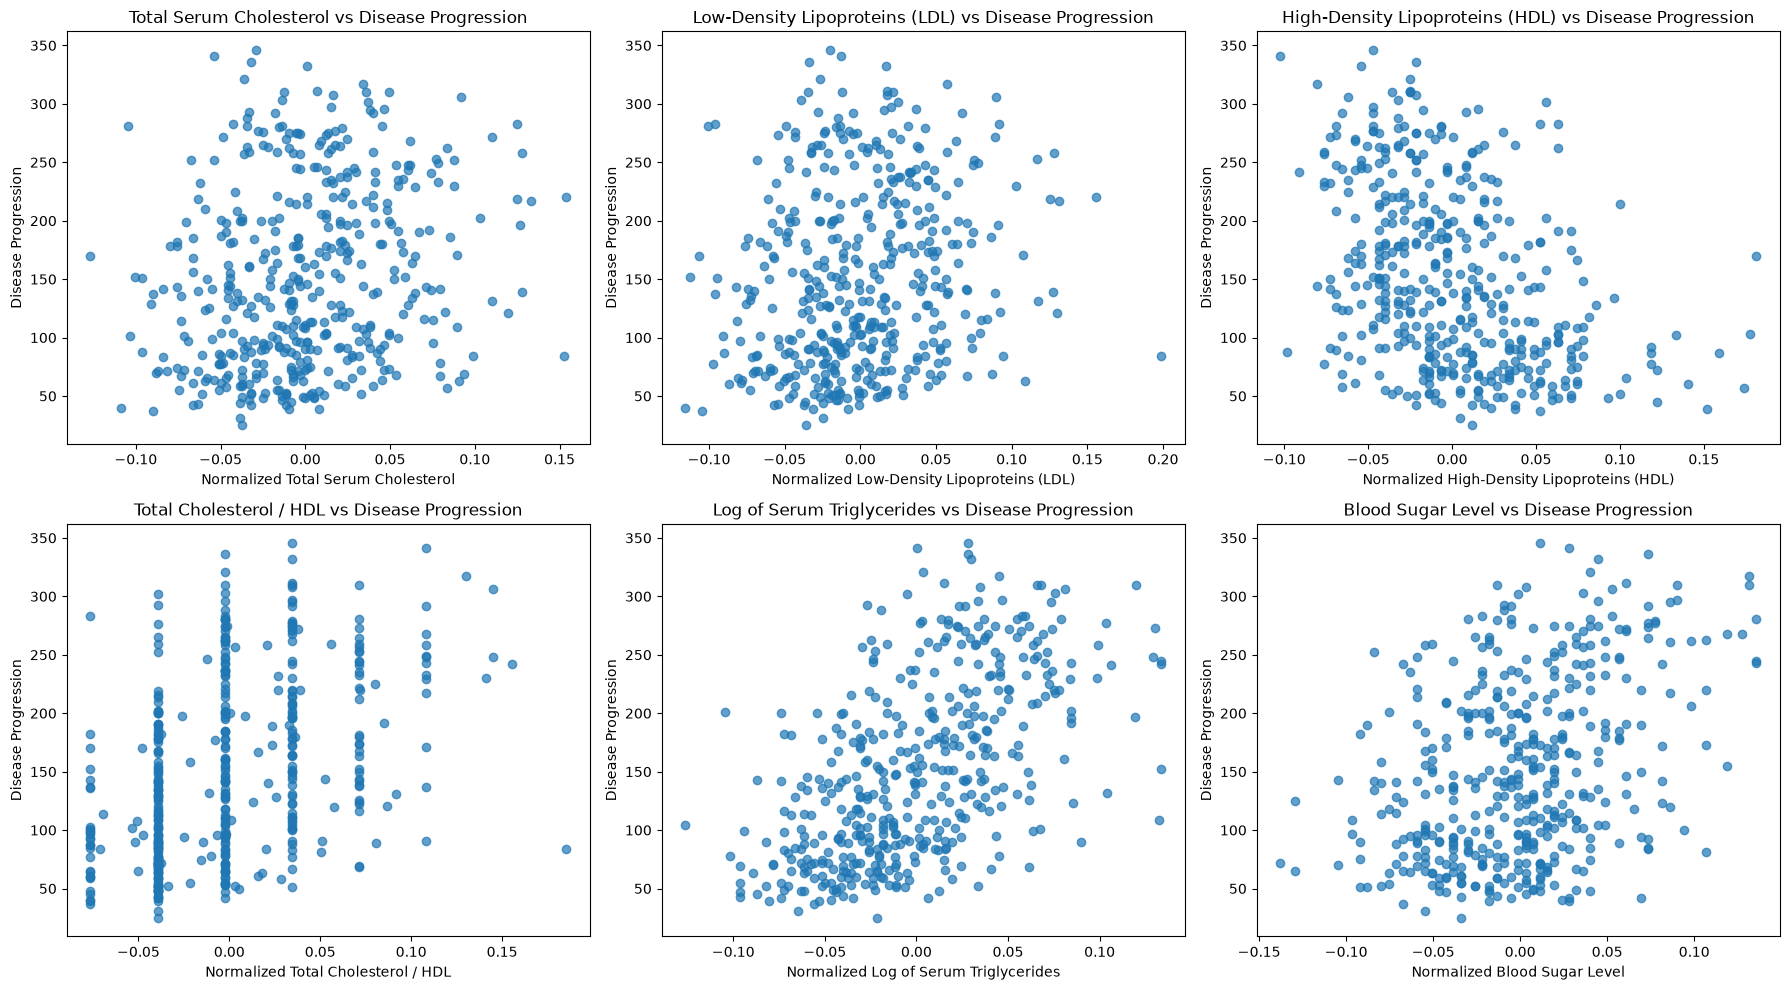

In [15]:
feature_titles = {
    "s1": "Total Serum Cholesterol",
    "s2": "Low-Density Lipoproteins (LDL)",
    "s3": "High-Density Lipoproteins (HDL)",
    "s4": "Total Cholesterol / HDL",
    "s5": "Log of Serum Triglycerides",
    "s6": "Blood Sugar Level",
}

features = ["s1", "s2", "s3", "s4", "s5", "s6"]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(diabetes_df[feature], diabetes_df["target"], alpha=0.7, color="tab:blue")
    readable_name = feature_titles.get(feature, feature)

    ax.set_xlabel(f"Normalized {readable_name}")
    ax.set_ylabel("Disease Progression")
    ax.set_title(f"{readable_name} vs Disease Progression")
plt.tight_layout()
plt.show()

**Answer:** The next 6 plots show the same relationships, but also colored by sex, allowing us to see if the relationships are different between males and females. Even though points of one color seem to be a little more shifted to one side than the other, it still doesn't form distinct clusters or different relationship types.

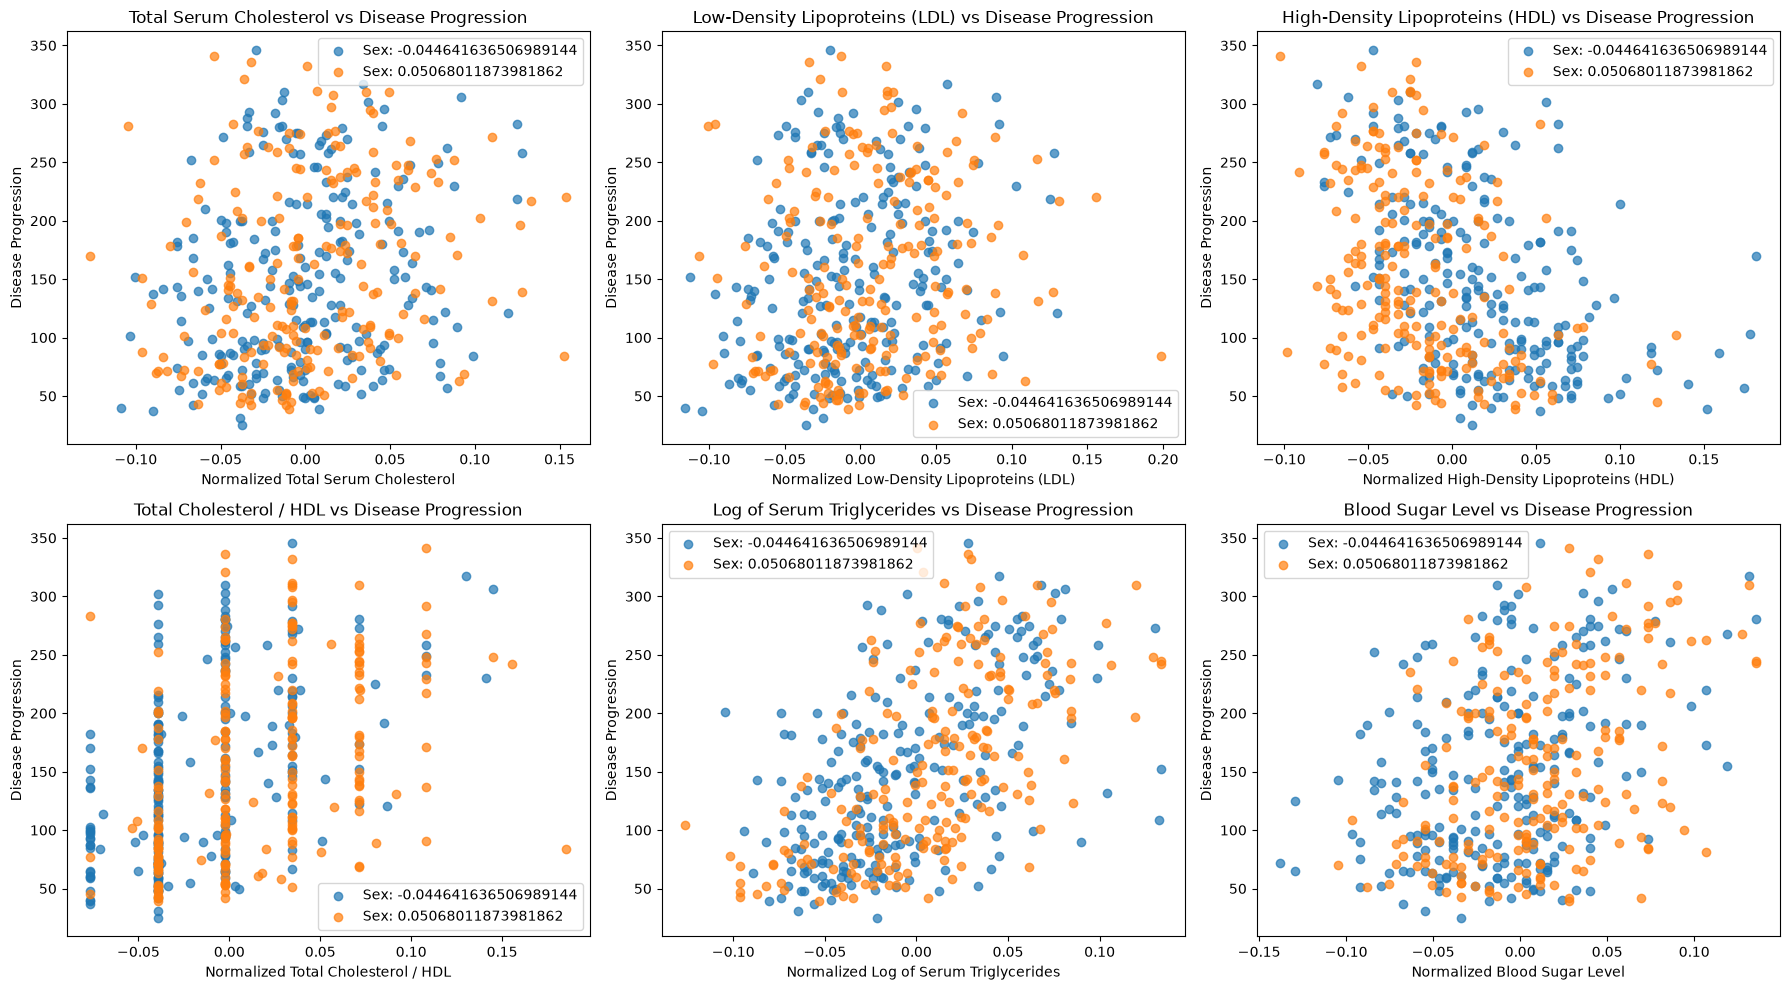

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    for sex_value, group in diabetes_df.groupby("sex"):
        ax.scatter(
            group[feature], group["target"], label=f"Sex: {sex_value}", alpha=0.7
        )
    readable_name = feature_titles.get(feature, feature)

    ax.set_xlabel(f"Normalized {readable_name}")
    ax.set_ylabel("Disease Progression")
    ax.set_title(f"{readable_name} vs Disease Progression")
    ax.legend()

plt.tight_layout()
plt.show()

### 3.3 Correlation

- Calculate correlation using ar least 2 different methods.
- Identify the predictor most strongly correlated with the target.
- Compare results.
- Explain why correlation is not sufficient for feature selection or causal interpretation.

In [17]:
target = "target"
dcor_results = []
corr_df = diabetes_df[features + ["target"]]
for feature in features:
    pair = corr_df[[feature, target]].dropna()
    dcor_results.append(
        {
            "feature": feature,
            "Pearson": pair[feature].corr(pair[target], method="pearson"),
            "Spearman": pair[feature].corr(pair[target], method="spearman"),
            "Distance correlation": dcor.distance_correlation(
                pair[feature].to_numpy(), pair[target].to_numpy()
            ),
        }
    )

pd.DataFrame(dcor_results).set_index("feature").round(3)

,Pearson,Spearman,Distance correlation
feature,,,
s1,0.212,0.232,0.227
s2,0.174,0.196,0.193
s3,-0.395,-0.410,0.390
s4,0.430,0.449,0.422
s5,0.566,0.589,0.565
s6,0.382,0.351,0.350


**Answers**:
- The most correlated predictor (across all the correlation methods) is s5, Log of Serum Triglycerides.
- The correlation doesn't change much between tried methods. The only "large change" seems to be for s3, where distance correlation is negative, compared to the other 2 being positive. However, this is just because the distance correlation doesn't show the direction of relationship.
- First of all, correlation doesn't mean causation, so the highly correlated features might be simply due to confounders, or the other way around, it might seem that there is no correlation, because we didn't count in all factors, that would make it look 0 numerically. Moreover, the obtained value depends on the chosen calculation method, we might get low correlation with one method but high with some other.

### 4.4 Simple regression

Choose one predictor and fit a simple linear regression. Report and interpret:

- intercept;
- slope;
- the scale of the predictor;
- whether the slope is a causal effect.

In [18]:
X_simple = diabetes_df[["s5"]]
y_simple = diabetes_df["target"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

Intercept: 152.13348416289585
Slope: 916.1373745509142


**Answers:** 
- Intercept and slope printed above;
- The predictor is in standardized units (also log scaled before);
- Slope in this case is not causal effect, as it is not triglycerides that cause the disease, but the other way around - their level rise due to the disease.

### 4.5 Residual diagnostics

Produce:

- observed versus predicted plot;
- residuals versus fitted plot;
- residual histogram;
- Q-Q plot.

Discuss linearity, homoscedasticity, residual normality, unusual observations, and any limitations of the diagnostics.

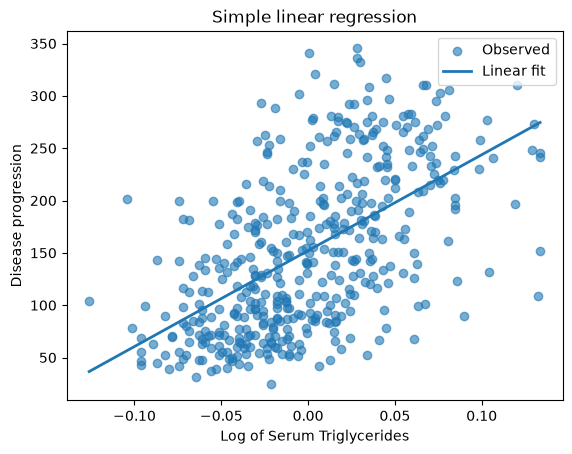

In [19]:
y_hat_simple = simple_model.predict(X_simple)

order = np.argsort(X_simple["s5"].to_numpy())

plt.scatter(X_simple["s5"], y_simple, alpha=0.6, label="Observed")

plt.plot(
    X_simple["s5"].to_numpy()[order],
    y_hat_simple[order],
    linewidth=2,
    label="Linear fit",
)

plt.xlabel(feature_titles["s5"])
plt.ylabel("Disease progression")
plt.title("Simple linear regression")
plt.legend()
plt.show()

In [20]:
y_hat_simple = simple_model.predict(X_simple)
residuals = y_simple.to_numpy() - y_hat_simple

residual_df = pd.DataFrame(
    {"observed": y_simple.to_numpy(), "predicted": y_hat_simple, "residual": residuals}
)

residual_df.head()

,observed,predicted,residual
0,151.0,170.371476,-19.371476
1,75.0,89.532400,-14.532400
2,141.0,154.754837,-13.754837
3,206.0,172.918575,33.081425
4,135.0,122.828412,12.171588


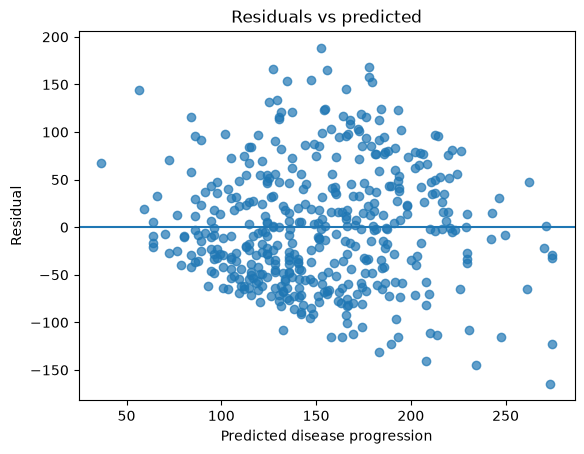

In [21]:
plt.scatter(residual_df["predicted"], residual_df["residual"], alpha=0.7)

plt.axhline(0)
plt.xlabel("Predicted disease progression")
plt.ylabel("Residual")
plt.title("Residuals vs predicted")
plt.show()

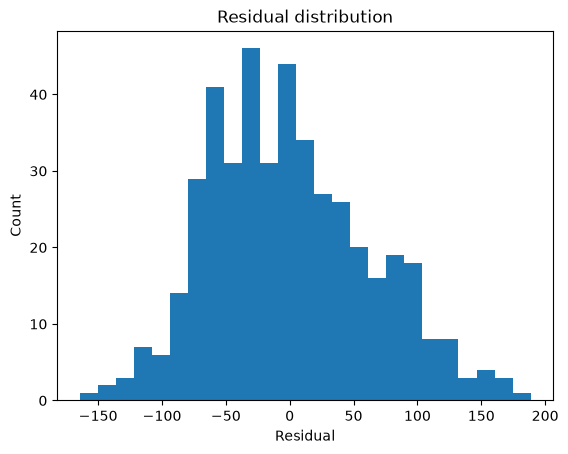

In [22]:
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()

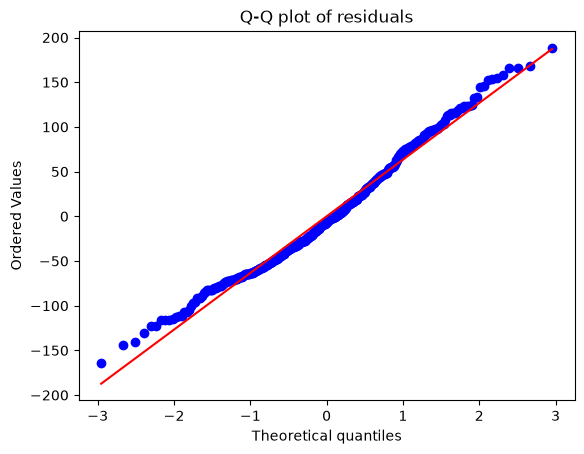

In [23]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.show()

**Answer:** The relationship doesn't look very linear, large spread of points around the line. Homoscedacity assumption doesn't seem to be satisfied, as residuals don't seem to be equally distributed/spread for different target prediction values. The distribution of residuals seems close to normal, but a bit skewed. Q-Q plot looks ok. With all that being said - linear model is not the best fit in this case. One of the limitations of this diagnostic is that it was done by looking at the plot, and it is hard to distinguish fine-details or establish "thresholds" doing it like that. 

### 4.6 Multiple regression and multicollinearity

Fit a model using all available predictors. Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity;
- whether standardized predictors change coefficient interpretation.

In [24]:
X_multiple = diabetes_df[features]
y_multiple = diabetes_df["target"]

multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y_multiple)

coef_table = pd.DataFrame(
    {"feature": X_multiple.columns, "coefficient": multiple_model.coef_}
)

coef_table

,feature,coefficient
0,s1,-897.962071
1,s2,693.560850
2,s3,22.277652
3,s4,-12.375126
4,s5,1070.736182
5,s6,223.877706


In [25]:
X_multiple.corr()

,s1,s2,s3,s4,s5,s6
s1,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


**Answers:**
- As s1 and s2 (Total Serum Cholesterol and Low-Density Lipoproteins (LDL)) are highly correlated (almost 0.9), taking them both into model might lead to coefficients destabilizing. Leaving one of them out might be a good idea in this case.
- Yes, as predictors are standardized, we can't say that their coefficients reflect some biological change that easily, as each predictor is now in standardized units, which can't even be turned back into original values, as we don't know the original max/min/mean values.

### 4.7 Train/test evaluation

Create a justified train/test split and report MAE, MSE, RMSE, and $R^2$. Compare simple and multiple regression on test data.

Explain whether the split answers the intended biological or clinical generalization question.

In [26]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [27]:
X = diabetes_df[features]
y = diabetes_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [28]:
results = []
m1 = LinearRegression()
m1.fit(X_train[["s5"]], y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test),
]:
    pred = m1.predict(X_split[["s5"]])
    metrics = regression_metrics(y_split, pred)
    results.append({"model": "s5 only", "split": split_name, **metrics})
metrics

{'MAE': 50.49295419490429,
 'MSE': 4026.5645842670797,
 'RMSE': np.float64(63.45521715562149),
 'R2': 0.3099882622961374}

In [29]:
m2 = LinearRegression()
m2.fit(X_train, y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test),
]:
    pred = m2.predict(X_split)
    metrics = regression_metrics(y_split, pred)
    results.append(
        {"model": "All physiological measurements", "split": split_name, **metrics}
    )
metrics

{'MAE': 48.44113311467883,
 'MSE': 3643.806790300394,
 'RMSE': np.float64(60.36395273920019),
 'R2': 0.37557950391351813}

In [30]:
X_train_m3 = X_train[[f for f in features if f != "s2"]]
X_test_m3 = X_test[[f for f in features if f != "s2"]]
m3 = LinearRegression()
m3.fit(X_train_m3, y_train)

for split_name, X_split, y_split in [
    ("train", X_train_m3, y_train),
    ("test", X_test_m3, y_test),
]:
    pred = m3.predict(X_split)
    metrics = regression_metrics(y_split, pred)
    results.append(
        {"model": "All physiological measurements", "split": split_name, **metrics}
    )
metrics

{'MAE': 48.50189719877963,
 'MSE': 3636.7945910282565,
 'RMSE': np.float64(60.30584209699966),
 'R2': 0.3767811485670768}

**Answers:**
- We can see that multiple regression performs a little better on the test set than simple one.
- The random split should be ok in this case for generalization, as one row corresponds to one person, and the split would also likely to result in similar proportions of males/females in both train and test.

### 4.8 Independent-task conclusion

Answer:

1. Which model generalized better?
2. Did adding more variables help?
3. Are any regression assumptions questionable?
4. Are coefficient interpretations straightforward?
5. What is one important limitation of the dataset or model?

Remember that the predictors from `load_diabetes()` are already standardized.

**Answers:**
1. The multiple regression generalized better (better metrics on test set).
2. Yes, but for highly correlated features it even hurt the MSE a bit (model 3 without s5 performs a little better with regard to this metric compared to model 2 including all features).
3. Yes, we don't really see linear relationship between target and features, the residuals in simple model didn't follow homoscedacity assumption.
4. No, as the predictors are standardized, their units are hard to decipher, especially because we don't know the parameters for the standardization. Therefore interpreting coefficients "biologically" is nearly impossible.
5. The biggest limitation is gonna be applying the models trained on this data to the other datasets. We don't know scaling parameters for each of the features, which makes it impossible to scale raw values from the other datasets in the same manner and therefore reuse the models.